# Tomography Analysis: Paranal Cn2 Profile

This notebook demonstrates the new "first-class" tomography support in `otbench`, including:
1.  **Vector Target Loading**: Loading the full `cn2_profile` task.
2.  **Granular Evaluation**: Using `detailed=True` to get per-altitude metrics.
3.  **Physics Check**: Calculating the `IntegratedSeeingMetric`.
4.  **Visualization**: Using `otbench.plot` to visualize profile structure and evolution.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import otbench.eval as eval_metrics
from otbench.tasks import TaskApi
from otbench.benchmark.models.forecasting.pytorch.recurrent_neural_network import RNNModel
from otbench.plot.tomography import plot_profile_comparison, plot_time_series_heatmap

## 1. Load Task and Data

In [5]:
task_api = TaskApi()
task_name = "forecasting.paranal_tomography_v2.full.cn2_profile_forecast"
task = task_api.get_task(task_name)

print(f"Task: {task.get_description()}")
print(f"Target: {task.get_target_name()}")

X_train, y_train = task.get_train_data()
X_test, y_test = task.get_test_data()

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")


Task: Forecasting task for Paranal Tomography Profile
Target: ['cn2_free_atmos_cn2_free_atmos_500', 'cn2_free_atmos_cn2_free_atmos_1000', 'cn2_free_atmos_cn2_free_atmos_2000', 'cn2_free_atmos_cn2_free_atmos_4000', 'cn2_free_atmos_cn2_free_atmos_8000', 'cn2_free_atmos_cn2_free_atmos_16000', 'cn2_boundary_cn2_boundary_1', 'cn2_boundary_cn2_boundary_2', 'cn2_boundary_cn2_boundary_3', 'cn2_boundary_cn2_boundary_4', 'cn2_boundary_cn2_boundary_5', 'cn2_boundary_cn2_boundary_6', 'cn2_boundary_cn2_boundary_7', 'cn2_boundary_cn2_boundary_8', 'cn2_ground_scalar']
X_train shape: (6352, 43)
y_train shape: (6352, 15)
X_test shape: (4749, 43)
y_test shape: (4749, 15)


In [7]:
# Apply Windowing (Lag Generation)
# This transforms (N, F) -> (N - Window, F * Window)
X_train, y_train = task.prepare_forecasting_data(X_train, y_train)
X_test, y_test = task.prepare_forecasting_data(X_test, y_test)

print(f"Windowed Input Shape: {X_train.shape}") # Should be (N, 43 * 20 = 860)

Windowed Input Shape: (6323, 1160)


In [8]:
physical_features_count = len(X_train.columns) // task.window_size
output_dim = y_train.shape[1] if y_train.ndim > 1 else 1

print(f"Derived Config: Input={physical_features_count}, Output={output_dim}")

Derived Config: Input=58, Output=15


## 2. Train Baseline Model (RNN)

In [9]:
model = RNNModel(
    name="RNNModel",
    target_name="cn2_ground_scalar",
    window_size=task.window_size,
    forecast_horizon=task.forecast_horizon,
    input_size=physical_features_count,
    output_size=output_dim,
    verbose=True
)
model.train(X_train, y_train)

# Determine output size context (if needed by nicer models)
output_size = y_train.shape[1]
print(f"Vector Target Size: {output_size}")

model: RNN(
  (rnn): RNN(58, 512, num_layers=2, batch_first=True)
  (fc): Linear(in_features=512, out_features=15, bias=True)
).
will normalize data before training
training data contains 58 features per timestep.
dataloader created with length 198.
at epoch 0. loss: 0.513974
at epoch 50. loss: 0.204180
at epoch 100. loss: 0.115999
at epoch 150. loss: 0.106895
at epoch 200. loss: 0.078948
at epoch 250. loss: 0.064458
at epoch 300. loss: 0.039714
at epoch 350. loss: 0.046516
at epoch 400. loss: 0.030881
at epoch 450. loss: 0.033889
Vector Target Size: 15


## 3. Granular Evaluation

In [10]:
# Evaluate with detailed_metrics=True
metrics, y_pred = task.evaluate_model(model.predict, return_predictions=True, detailed_metrics=True)

print("Overall Metrics:")
for k, v in metrics.items():
    if k in ["detailed_score", "seeing_true", "seeing_pred"]:
        continue
    if isinstance(v, dict):
        print(f"{k}: {v['metric_value']:.4e}")

# Inspect detailed scores (e.g. RMSE per layer)
rmse_detailed = metrics['root_mean_square_error']['detailed_score']
layers = task.get_target_name()
print("\nPer-Layer RMSE:")
for layer, score in zip(layers, rmse_detailed):
    print(f"{layer}: {score:.4e}")

validation data contains 58 features.
dataloader created with length 4720.
Overall Metrics:
root_mean_square_error: 1.8346e+00
mean_absolute_error: 1.4379e+00

Per-Layer RMSE:
cn2_free_atmos_cn2_free_atmos_500: 1.0925e+00
cn2_free_atmos_cn2_free_atmos_1000: 1.2125e+00
cn2_free_atmos_cn2_free_atmos_2000: 1.5138e+00
cn2_free_atmos_cn2_free_atmos_4000: 6.7643e-01
cn2_free_atmos_cn2_free_atmos_8000: 7.3066e-01
cn2_free_atmos_cn2_free_atmos_16000: 2.5762e-01
cn2_boundary_cn2_boundary_1: 7.6559e-01
cn2_boundary_cn2_boundary_2: 1.5751e+00
cn2_boundary_cn2_boundary_3: 3.4554e+00
cn2_boundary_cn2_boundary_4: 3.0043e+00
cn2_boundary_cn2_boundary_5: 3.0916e+00
cn2_boundary_cn2_boundary_6: 3.2025e+00
cn2_boundary_cn2_boundary_7: 3.3002e+00
cn2_boundary_cn2_boundary_8: 3.3208e+00
cn2_ground_scalar: 3.1949e-01


## 4. Physics Check: Integrated Seeing

In [11]:
# Calculate integrated seeing metric
# Note: need to parse heights properly or assume uniform for this demo
res_seeing = eval_metrics.integrated_seeing(y_test, y_pred, detailed=True)
print(f"Integrated Seeing RMSE (arcsec error): {res_seeing['metric_value']:.4f}")

Integrated Seeing RMSE (arcsec error): 0.0000


## 5. Visualization

<Figure size 1000x800 with 0 Axes>

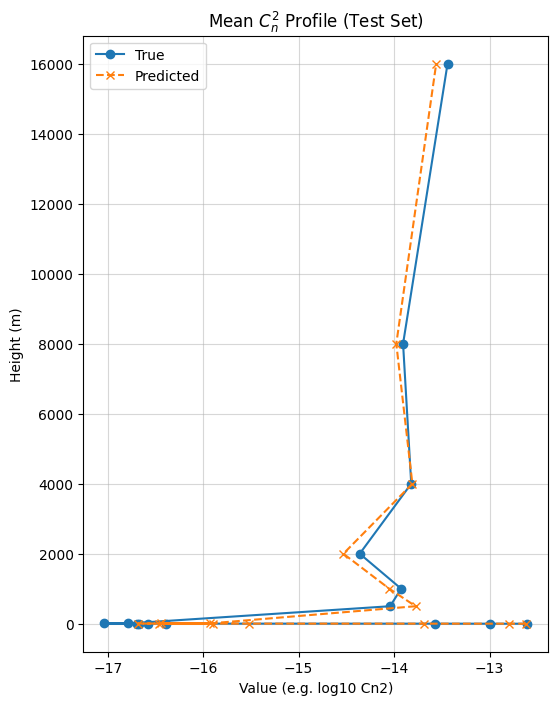

In [12]:
plt.figure(figsize=(10, 8))
plot_profile_comparison(y_test, y_pred, feature_names=task.get_target_name(), title=r"Mean $C_n^2$ Profile (Test Set)")
plt.show()

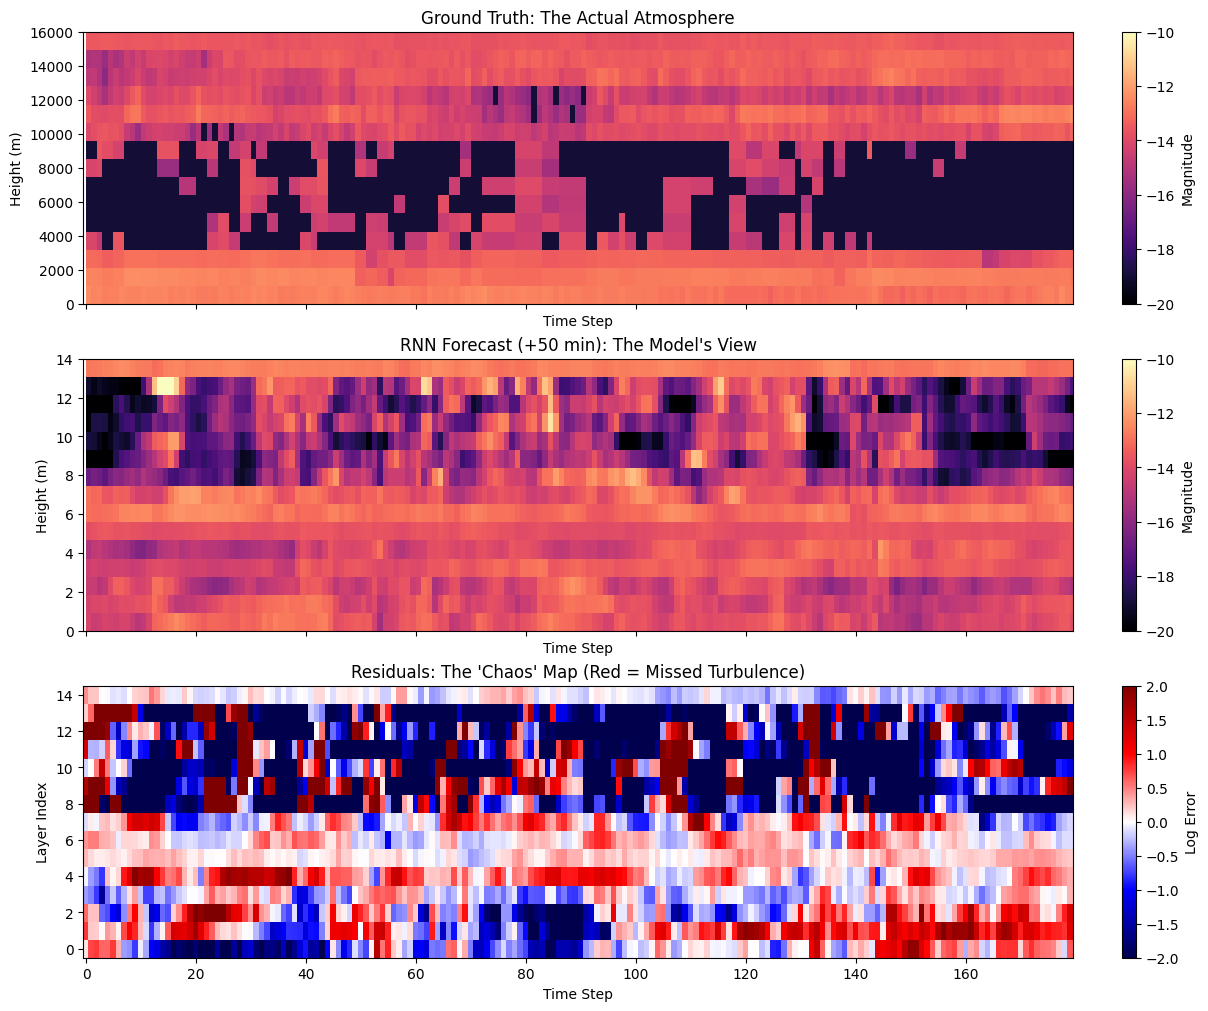

In [16]:
import matplotlib.pyplot as plt

from otbench.plot.tomography import plot_time_series_heatmap

# 1. Slice a dynamic event (e.g., a 3-hour window)
# We choose a window where turbulence actually changes to see if RNN reacts
window = slice(1000, 1180) 

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 10), sharex=True, constrained_layout=True)

# A. Ground Truth (The Reality)
plot_time_series_heatmap(
    y_test.iloc[window], 
    ax=ax1, 
    title="Ground Truth: The Actual Atmosphere",
    cmap="magma",
    vmin=-20,
    vmax=-10,
)

# B. RNN Forecast (The Prediction)
plot_time_series_heatmap(
    y_pred[window], 
    ax=ax2, 
    title=f"RNN Forecast (+{task.forecast_horizon*5} min): The Model's View",
    cmap="magma",
    vmin=-20,
    vmax=-10,
)

# C. The Error Map (Where did we fail?)
# Red = Underpredicted, Blue = Overpredicted
error_map = y_test.iloc[window].values - y_pred[window]
im = ax3.imshow(error_map.T, aspect='auto', origin='lower', cmap='seismic', vmin=-2, vmax=2)
ax3.set_title("Residuals: The 'Chaos' Map (Red = Missed Turbulence)")
ax3.set_ylabel("Layer Index")
ax3.set_xlabel("Time Step")
plt.colorbar(im, ax=ax3, label="Log Error")

plt.show()